# Multi-Agent Collaboration

An interesting finding from taking [Learning in Games, Games in Learning](https://mlgametheory.com/) with Aaron Roth last Fall (2025) was the fact that multi-agent learning in collaborative games is pretty hard.

Consider the following example. There are $N$ players on a team who must select from amongst $K$ actions. All players have the same set of actions and the payoff is determined by how many of each action is taken. Importantly, all agents recieve the same payoff (i.e. no competition). 

A canonical example I think of is coding agents. Suppose you have a team of $N=5$ codings agents that can select from $K=3$ roles $\{\text{developer, tester, manager}\}$. The utility of the team is dependent not only on how many there are of each role, but also by who takes on which role.

Formally we write that the action space for the entire multi-agent system is the cross-product 
$$\mathcal{A} = \mathcal{A}_1 \times \mathcal{A}_2 \times \ldots \times \mathcal{A}_N \quad \text{where } |\mathcal{A_i}| = K$$

The shared utility of the each agent (or the system overall) is given by 
$$U: \mathcal A \rightarrow \mathbb{R} \quad \text{or}\quad U: \mathcal{A}_1 \times \mathcal{A}_2 \times \ldots \times \mathcal{A}_N  \rightarrow \mathbb{R}$$
 
Each of the $N$ players can play a distribution $p_i \in \Delta{\mathcal{A_i}}$ over their actions leading the the joint action distirbution $$p = \prod_i p_i$$

The following will put some of these ideas into code. 

In [7]:
import numpy as np

N=5
K=3

def utility_vector(U, P, i):
    # For each action k for player i, compute expected utility if i plays k and others play P[:-i]
    N, K = P.shape
    others = [j for j in range(N) if j != i]
    res = np.zeros(K)
    for k in range(K):
        # New action distribution matrix with player i deterministically on action k
        P_new = P.copy()
        P_new[i] = 0
        P_new[i, k] = 1
        # Full expected utility for this player
        idx_grids = np.indices([K]*N).reshape(N,-1).T  # Shape: (K**N, N)
        # Probability of each joint action profile
        probs = np.prod(P_new[np.arange(N)[:,None], idx_grids.T], axis=0)
        # Utilities for player i (all agents share payoff, so utility same for all) 
        util = U[tuple(idx_grids.T)]
        res[k] = np.sum(util * probs)
    return res

def team_utility(U, P):
    N, K = P.shape
    idx_grids = np.indices([K]*N).reshape(N,-1).T
    probs = np.prod(P[np.arange(N)[:,None], idx_grids.T], axis=0)
    util = U[tuple(idx_grids.T)]
    return np.sum(util * probs)

def max_team_utility(U):
    max_val = np.max(U)
    max_idx_flat = np.argmax(U)
    max_idx = np.unravel_index(max_idx_flat, U.shape)
    return max_val, max_idx




### The pitfalls of greedy improvement in a group

Given some initial distribution over all players $p^0(a) = \prod_i p^0_i(a)$. If every player individually tries to improve their utility (hence the overall utility) do we reach a "good" solution?

specifically, let $p_i^t$ denote the action distribution of player $i$ at time $t$. The player faces expected utility given by the vector 
$$u_i(p_{-i}) = \mathbb{E}_{a_{-i} \sim p_{-i}}\left[U(a_i, a_{-i})\right]$$ 
where the $k$ th element is the utility of player $i$ playing action $k$.

Given this utility vector, Multiplicative Weights is a greedy algorithm every agent can use to update their probabiltiy vectors. It is equivalent to gradient ascent on utility if our vector $p$ were "pre-softmax" logits as opposed to probabilities.

The multiplicative weights update for player $i$ is as follows given
Let $$p_i^t \triangleq i\text{'s action dist. at time }t, \quad u_i^t \triangleq i\text{'s utility function at time }t, \quad \eta \triangleq \text{learning rate}$$ 

1) For each action $k$:
$$
p_i^{t+1}(k) \propto p_i^t(k) \cdot \exp(\eta \, u_i^t(k))
$$

2) After multiplying, renormalize so that
$$
\sum_k p_i^{t+1}(k) = 1
$$

<!-- Here, $\eta > 0$ is the learning rate. -->



In [8]:
# One fixed game; five MW runs differ only in random initial product distributions.
import random
master_seed = random.randint(0, 2**32 - 1)  # Generate a random seed using Python's random module
print(f"Using master seed: {master_seed}")
rng_master = np.random.default_rng(master_seed)
U = rng_master.random((K,)*N)
print(U.shape)
U = rng_master.normal(size=(K,)*N)
print(U.shape)

max_utility, _ = max_team_utility(U)

def random_product_simplex(rng, N, K):
    P = rng.random((N, K))
    P /= P.sum(axis=1, keepdims=True)
    return P

num_iterations = 400
eta = 0.2

n_runs = 5
all_util_hist = []
all_P_hist = []

for run in range(n_runs):
    rng = np.random.default_rng(100 + run)
    P = random_product_simplex(rng, N, K)
    P_hist = [P.copy()]
    util_hist = [team_utility(U, P)]
    for t in range(num_iterations):
        P_new = np.zeros_like(P)
        for i in range(N):
            u_vec = utility_vector(U, P, i)
            weights = P[i] * np.exp(eta * u_vec)
            if np.sum(weights) > 0:
                P_new[i] = weights / np.sum(weights)
            else:
                P_new[i] = np.full(K, 1.0 / K)
        P = P_new
        P_hist.append(P.copy())
        util_hist.append(team_utility(U, P))
    all_util_hist.append(np.array(util_hist))
    all_P_hist.append(np.array(P_hist))

all_util_hist = np.stack(all_util_hist, axis=0)  # (n_runs, num_iterations+1)
final_utils = all_util_hist[:, -1]
median_idx = int(np.argsort(final_utils)[n_runs // 2])

P_hist = all_P_hist[median_idx]
util_hist = all_util_hist[median_idx]


Using master seed: 3513332093
(3, 3, 3, 3, 3)
(3, 3, 3, 3, 3)


In [9]:
max_team_utility(U)

def random_product_simplex(rng, N, K):
    P = rng.random((N, K))
    P /= P.sum(axis=1, keepdims=True)
    return P

num_iterations = 400
eta = 0.2

n_runs = 5
all_util_hist = []
all_P_hist = []

for run in range(n_runs):
    rng = np.random.default_rng(100 + run)
    P = random_product_simplex(rng, N, K)
    P_hist = [P.copy()]
    util_hist = [team_utility(U, P)]
    for t in range(num_iterations):
        P_new = np.zeros_like(P)
        for i in range(N):
            u_vec = utility_vector(U, P, i)
            weights = P[i] * np.exp(eta * u_vec)
            if np.sum(weights) > 0:
                P_new[i] = weights / np.sum(weights)
            else:
                P_new[i] = np.full(K, 1.0 / K)
        P = P_new
        P_hist.append(P.copy())
        util_hist.append(team_utility(U, P))
    all_util_hist.append(np.array(util_hist))
    all_P_hist.append(np.array(P_hist))

all_util_hist = np.stack(all_util_hist, axis=0)  # (n_runs, num_iterations+1)
final_utils = all_util_hist[:, -1]
median_idx = int(np.argsort(final_utils)[n_runs // 2])

P_hist = all_P_hist[median_idx]
util_hist = all_util_hist[median_idx]


In [10]:
%%capture
!pip install mpltern

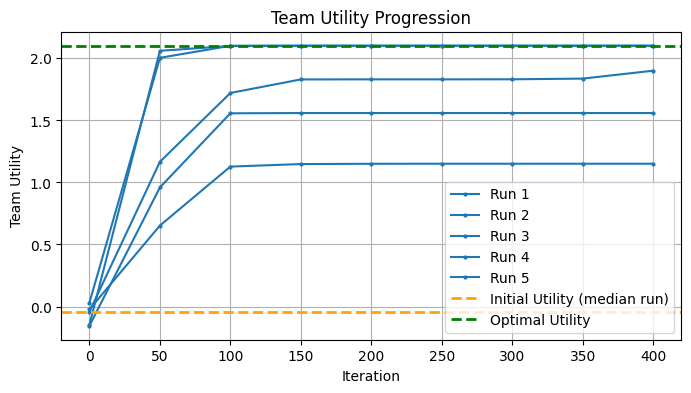

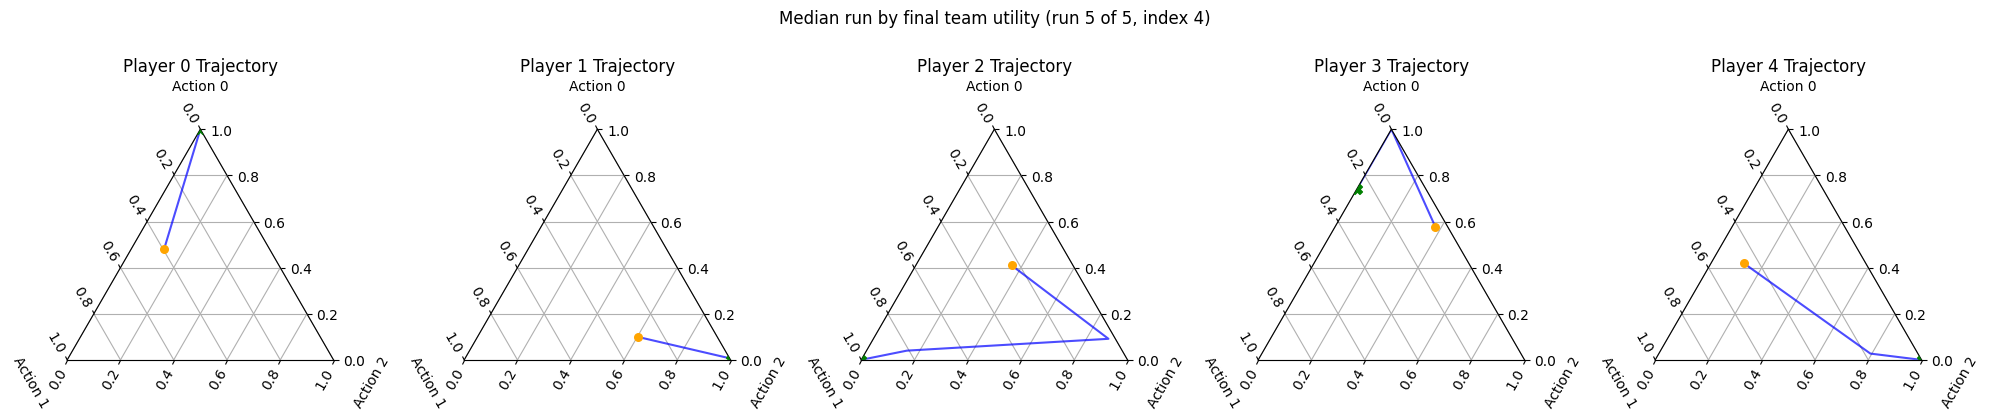

In [11]:
import matplotlib.pyplot as plt
import mpltern
import numpy as np

# Subsample paths for faster drawing (every `plot_step` iterations; always include last)
plot_step = 50
n_pts = all_util_hist.shape[1]
plot_idx = np.unique(np.r_[np.arange(0, n_pts, plot_step), n_pts - 1])

# 1. Plot team utility — all runs with the same line width
lw = plt.rcParams["lines.linewidth"]

plt.figure(figsize=(8, 4))
for i in range(n_runs):
    plt.plot(
        plot_idx,
        all_util_hist[i, plot_idx],
        marker="o",
        markersize=2,
        linewidth=lw,
        color="C0",
        alpha=1.0,
        label=f"Run {i + 1}",
    )
plt.axhline(
    all_util_hist[median_idx, 0],
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Initial Utility (median run)",
)
plt.axhline(max_utility, color="green", linestyle="--", linewidth=2, label="Optimal Utility")
plt.xlabel('Iteration')
plt.ylabel('Team Utility')
plt.title('Team Utility Progression')
plt.legend()
plt.grid(True)
plt.show()

# 2. Simplex trajectories for P_hist only (not all five runs).
# P_hist is the median run: the one whose *final* team utility is the median of the
# five finals (0-based index median_idx; same run as util_hist in the cell above).
fig, axes = plt.subplots(1, N, figsize=(4 * N, 4), subplot_kw={'projection': 'ternary'})
fig.suptitle(
    f"Median run by final team utility (run {median_idx + 1} of {n_runs}, index {median_idx})",
    y=1.02,
)

# Ensure axes is iterable if N=1
if N == 1:
    axes = [axes]

for i in range(N):
    # P_hist is assumed to be (Iterations, Players, Actions)
    # Map actions to Top (0), Left (1), and Right (2) corners
    Ph = P_hist[plot_idx]
    t = Ph[:, i, 0]
    l = Ph[:, i, 1]
    r = Ph[:, i, 2]

    # Plot the trajectory (subsampled; start/end markers use true endpoints below)
    axes[i].plot(t, l, r, label=f'Player {i}', color='blue', alpha=0.7)
    
    # Optional: Mark the start and end points
    axes[i].scatter(
        P_hist[0, i, 0], P_hist[0, i, 1], P_hist[0, i, 2],
        color='orange', s=30, label='Start', zorder=5,
    )
    axes[i].scatter(
        P_hist[-1, i, 0], P_hist[-1, i, 1], P_hist[-1, i, 2],
        color='green', marker='X', s=50, label='End', zorder=5,
    )
    
    # Labels
    axes[i].set_tlabel('Action 0')
    axes[i].set_llabel('Action 1')
    axes[i].set_rlabel('Action 2')
    axes[i].set_title(f'Player {i} Trajectory')
    axes[i].grid()

plt.tight_layout()
plt.show()


### Why are we suboptimal?
The reason these agents are suboptimal are because they are (i) acting and (ii) learning independetly from eachother. There is a distinction worth noting here. 

##### Acting
In a general $n$-player games, correlated equilibria are much easier to find then nash (independent) equilibria. For those not familiar with variety of game theory solution concepts, what I am saying is that the "optimal" joint-distribuion for our game may not factorize into independent distributions. In math:
$$p^* \not \in \left\{\prod_i p_i\right\}$$
For collaborative games we are saved from pitfall (i) because the welfare-maximizing equilibrium is just the joint distribution where all weight is on the argmax action of $U$
$$ p^* = \delta\left( \argmax_a U(a)  \right)$$
Clearly this factorizes in to a product of marginal distributions since if action $(i, j, k, \ell)$ was the optimal action, then players 1 - 4 would place all weight on action $i, j, k, l$ respectively.

##### Learning

I actually don't know or think there is a simple way to decouple communication in acting and communication in learning. That is to say, in the standard 2 player collaboration game each can run MW on their distributions $p^t$ and $q^t$. During the MW steps they each recieve as information $Uq$ or $U^\top p$ as information about the others payoffs with respect to the opponent's actions. I thought it might be the case that going to a one-vector from the full matrix joint-utility $U$ there would be some suboptimality. However, I could not, after talking with Claude, uncover any algorithms that found a method where $p$ and $q$ would take in the full matrix $U$ and reliably provide a "better" product of marginals solution to the game.

That is to say this: $\text{\textcolor{red}{communication in learning is best (perhaps only) taken advantage of when communication in actions is also enabled}}$

~~Assuming that the optimal distribution lives in the space we are optimizing in (i.e. the space of product distributions) then there is still another hiccup in our current setup.~~ 

~~When an agent chooses to update their probability mass, they have neither knowledge about (a) how others will change their weights nor (b) how that change will affect their own utilty. Optimization is being done while some agents are blind to the full optimization landscape they live in. Let me formalize this first.~~

~~Ok so the thing I was going to try actually does not work. That is, *there is no common algorithm to solve the following problem*. Set a baseline utility of mean.~~

~~If we are optimizing the joint distribution of two agents in a game each with $K$ actions. The joint-probability of playing player 1 playing $i$ and player 2 playing $j$ is $p(i, j)$.~~ 





### The cost of coordination. 
In order to coordinate, a subset of players can move from learning only in their action space but rather by collaborating with another player to learn a joint-action distribution. Obviously, if we just bring all players into a single joint distribuion then we can just optimize directly over $\Delta({\mathcal{A}})$ and this would be trivial. 

However the size of the joint distribution and joint payoff matrix grows exponentially as we add more players. It also reduces opportunity for parallelism. An interesting question is this. Is it possibel to create sub collaborative groups that together learn joint-actions that relax the optimization landscape of multiplicative weighs. 

I have an idea for an experiment: create a game with N=3 agents and K=10 actions. Have one version where the payoffs are randn and another when the payoffs are random. run the following versions of the simultaneous multipliative weights algorithm iplemented above. For each run 10 seeds where the starting positions on the simplex are randomized. 
1) just standard MW exactly like above
2) join players 1-2, 2-3, 3-1 and run the MW between two "players". One plaer is the unjoined player and the other player is the combined joint player which can be optimized as one. 
3) Run multiplicative weights on all players (just find the optimal distribution for a linear payoff (should be a very easy problem))

$\text{\textcolor{red}{TODO}}$